In [2]:
!git clone https://github.com/Deeptixx/ceam_task_1.git

fatal: destination path 'ceam_task_1' already exists and is not an empty directory.


In [3]:
import os
import numpy as np
import tensorflow as tf
import random
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-06-11 14:05:51.388806: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781186751.412669   10141 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781186751.420412   10141 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781186751.439474   10141 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781186751.439497   10141 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781186751.439500   10141 computation_placer.cc:177] computation placer alr

In [4]:
data_dir = '/kaggle/working/ceam_task_1/dataset'
classes = ['phone', 'book', 'headphones', 'calculator', 'clock']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
image_paths = []
labels = []
for class_name in classes:
    class_dir = os.path.join(data_dir, class_name)
    for img_file in os.listdir(class_dir):
        if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
            image_paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_idx[class_name])
print(f"Total images: {len(image_paths)}")
print(f"Class distribution: {np.bincount(labels)}")

Total images: 125
Class distribution: [25 25 25 25 25]


In [5]:
images = []
for img_path in image_paths:
    img = keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = keras.preprocessing.image.img_to_array(img)
    images.append(img_array)
images = np.array(images)
labels = np.array(labels)
print(f"Images shape: {images.shape}")  #(125,224,224,3)
print(f"Labels shape: {labels.shape}")  #(125,)
images = images / 255.0 #normalizing pixel values

Images shape: (125, 224, 224, 3)
Labels shape: (125,)


In [6]:
# 70% train 15% val 15% test
train_images, temp_images, train_labels, temp_labels = train_test_split(
    images, labels, test_size=0.3, random_state=SEED, stratify=labels
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")
print(f"\nTrain class distribution: {np.bincount(train_labels)}")
print(f"Val class distribution: {np.bincount(val_labels)}")
print(f"Test class distribution: {np.bincount(test_labels)}")

Train: 87, Val: 19, Test: 19

Train class distribution: [17 18 17 17 18]
Val class distribution: [4 3 4 4 4]
Test class distribution: [4 4 4 4 3]


In [7]:
def create_baseline_model(dropout_rate=0.5):
    model = models.Sequential([
        layers.Conv2D(32, kernel_size=3, activation='relu', padding='same', 
                      input_shape=(224, 224, 3)),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(128, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(5, activation='softmax')
    ])
    
    return model
model = create_baseline_model(dropout_rate=0.5)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1781186771.597517   10141 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781186771.602925   10141 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model_sgd = create_baseline_model(dropout_rate=0.5)
model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.0001),  # 0.001 → 0.0001
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_sgd = model_sgd.fit(
    train_images, train_labels,
    batch_size=8,
    epochs=50,
    validation_data=(val_images, val_labels),
    verbose=1
)
test_loss_sgd, test_acc_sgd = model_sgd.evaluate(test_images, test_labels, verbose=0)
print(f"SGD (lr=0.0001) Test Accuracy: {test_acc_sgd*100:.2f}%")

Epoch 1/50


I0000 00:00:1781186777.960535   10206 service.cc:152] XLA service 0x7b83f0002cd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781186777.960587   10206 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781186777.960595   10206 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781186778.135597   10206 cuda_dnn.cc:529] Loaded cuDNN version 91002


 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1116 - loss: 1.6167

I0000 00:00:1781186780.950410   10206 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-06-11 14:06:22.083024: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-11 14:06:22.227028: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 478ms/step - accuracy: 0.1494 - loss: 1.6136 - val_accuracy: 0.2105 - val_loss: 1.6055
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2184 - loss: 1.6083 - val_accuracy: 0.2105 - val_loss: 1.6055
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2529 - loss: 1.6021 - val_accuracy: 0.2105 - val_loss: 1.6055
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1724 - loss: 1.6126 - val_accuracy: 0.2105 - val_loss: 1.6055
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1954 - loss: 1.6070 - val_accuracy: 0.2105 - val_loss: 1.6055
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2069 - loss: 1.6095 - val_accuracy: 0.2105 - val_loss: 1.6055
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1609 - loss: 1.6133 - val_accuracy: 0.2105 - val_loss: 1.6055
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1724 - loss: 1.6141 - val_accuracy: 0.2105 - val_loss: 1

In [9]:
model_rms = create_baseline_model(dropout_rate=0.5)
model_rms.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_rms = model_rms.fit(
    train_images, train_labels,
    batch_size=8,
    epochs=50,
    validation_data=(val_images, val_labels),
    verbose=1
)
test_loss_rms, test_acc_rms = model_rms.evaluate(test_images, test_labels, verbose=0)
print(f"RMSprop Test Accuracy: {test_acc_rms*100:.2f}%")

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 302ms/step - accuracy: 0.2069 - loss: 1.6329 - val_accuracy: 0.2105 - val_loss: 1.6064
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2414 - loss: 1.6123 - val_accuracy: 0.2105 - val_loss: 1.5985
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2529 - loss: 1.6014 - val_accuracy: 0.2105 - val_loss: 1.5897
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2184 - loss: 1.5928 - val_accuracy: 0.2105 - val_loss: 1.5622
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2414 - loss: 1.5772 - val_accuracy: 0.2105 - val_loss: 1.5376
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2414 - loss: 1.5498 - val_accuracy: 0.2105 - val_loss: 1.5009
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2414 - loss: 1.5618 - val_accuracy: 0.2105 - val_loss: 1.4757
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2069 - loss: 1.5386 - val_accuracy: 0.2105 - 

In [12]:
model_adagrad = create_baseline_model(dropout_rate=0.5)

model_adagrad.compile(
    optimizer=keras.optimizers.Adagrad(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_adagrad = model_adagrad.fit(
    train_images, train_labels,
    batch_size=8,
    epochs=50,
    validation_data=(val_images, val_labels),
    verbose=1
)

test_loss_adagrad, test_acc_adagrad = model_adagrad.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print(f"Adagrad Test Accuracy: {test_acc_adagrad*100:.2f}%")

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 305ms/step - accuracy: 0.2069 - loss: 1.6157 - val_accuracy: 0.0526 - val_loss: 1.6102
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1954 - loss: 1.6270 - val_accuracy: 0.1053 - val_loss: 1.6100
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1379 - loss: 1.6170 - val_accuracy: 0.1579 - val_loss: 1.6096
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1724 - loss: 1.6140 - val_accuracy: 0.1053 - val_loss: 1.6091
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1724 - loss: 1.6105 - val_accuracy: 0.2105 - val_loss: 1.6080
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1724 - loss: 1.6194 - val_accuracy: 0.2105 - val_loss: 1.6074
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2644 - loss: 1.6090 - val_accuracy: 0.2105 - val_loss: 1.6067
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1839 - loss: 1.6237 - val_accuracy: 0.2105 - 

In [16]:
model_adam = create_baseline_model(dropout_rate=0.5)

model_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_adam = model_adam.fit(
    train_images, train_labels,
    batch_size=8,
    epochs=50,
    validation_data=(val_images, val_labels),
    verbose=1
)

test_loss_adam, test_acc_adam = model_adam.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print(f"Adam Test Accuracy: {test_acc_adam*100:.2f}%")

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 319ms/step - accuracy: 0.2069 - loss: 1.6283 - val_accuracy: 0.2632 - val_loss: 1.6042
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2184 - loss: 1.6152 - val_accuracy: 0.2105 - val_loss: 1.5998
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1839 - loss: 1.6107 - val_accuracy: 0.2632 - val_loss: 1.5955
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2299 - loss: 1.6033 - val_accuracy: 0.2632 - val_loss: 1.5827
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2069 - loss: 1.5960 - val_accuracy: 0.2105 - val_loss: 1.5639
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2299 - loss: 1.5846 - val_accuracy: 0.2105 - val_loss: 1.5239
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1954 - loss: 1.5499 - val_accuracy: 0.3684 - val_loss: 1.4785
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2529 - loss: 1.5235 - val_accuracy: 0.3684 - 

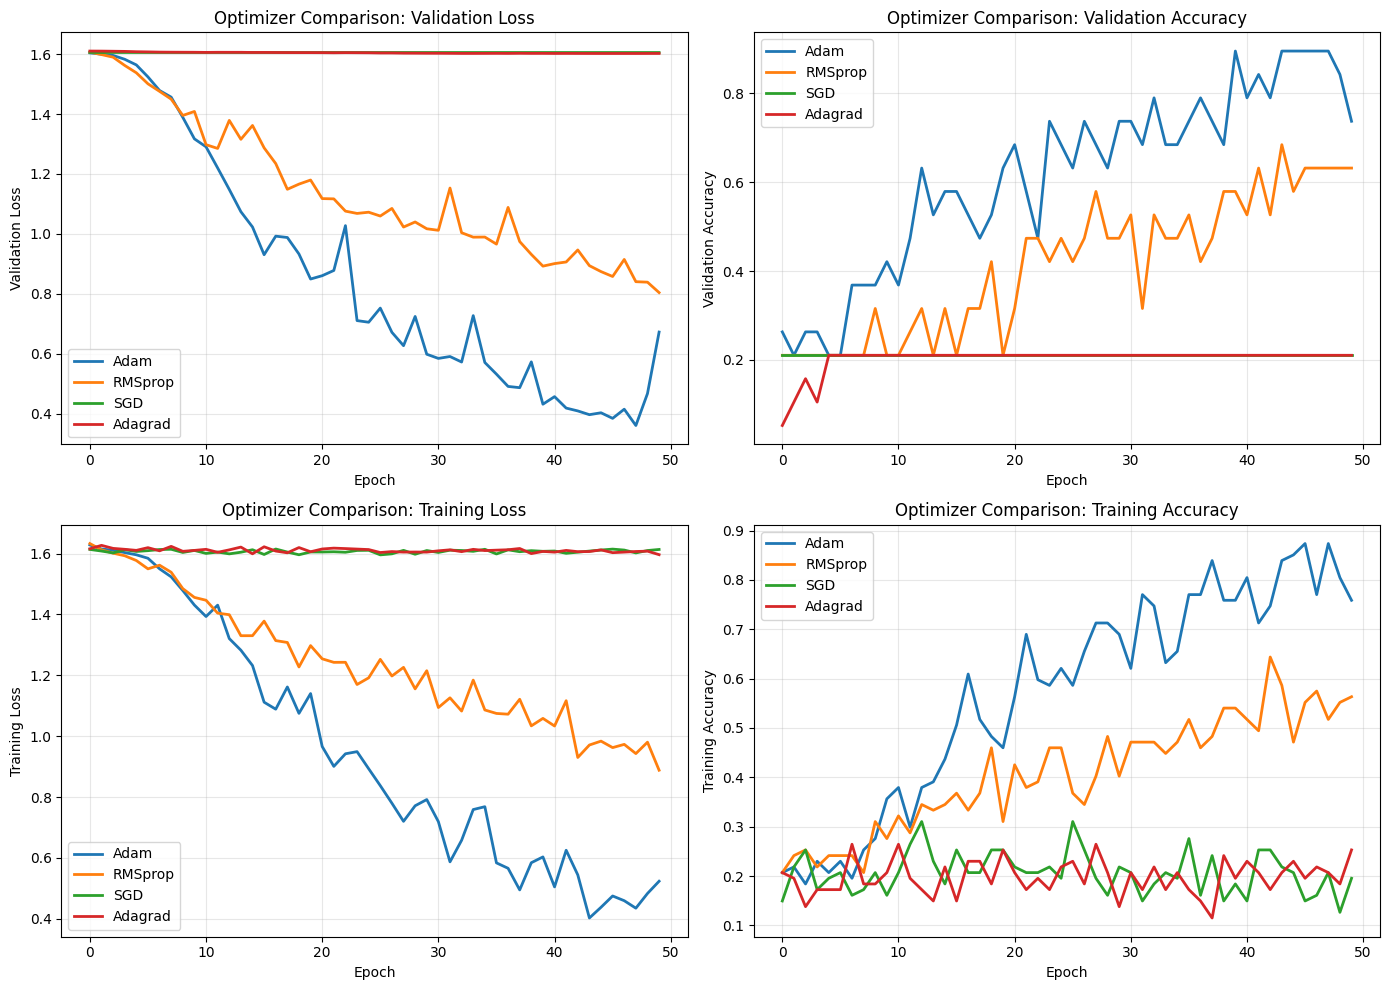

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Validation Loss
axes[0, 0].plot(history_adam.history['val_loss'], label='Adam', linewidth=2)
axes[0, 0].plot(history_rms.history['val_loss'], label='RMSprop', linewidth=2)
axes[0, 0].plot(history_sgd.history['val_loss'], label='SGD', linewidth=2)
axes[0, 0].plot(history_adagrad.history['val_loss'], label='Adagrad', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Validation Loss')
axes[0, 0].set_title('Optimizer Comparison: Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Validation Accuracy
axes[0, 1].plot(history_adam.history['val_accuracy'], label='Adam', linewidth=2)
axes[0, 1].plot(history_rms.history['val_accuracy'], label='RMSprop', linewidth=2)
axes[0, 1].plot(history_sgd.history['val_accuracy'], label='SGD', linewidth=2)
axes[0, 1].plot(history_adagrad.history['val_accuracy'], label='Adagrad', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Validation Accuracy')
axes[0, 1].set_title('Optimizer Comparison: Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Training Loss
axes[1, 0].plot(history_adam.history['loss'], label='Adam', linewidth=2)
axes[1, 0].plot(history_rms.history['loss'], label='RMSprop', linewidth=2)
axes[1, 0].plot(history_sgd.history['loss'], label='SGD', linewidth=2)
axes[1, 0].plot(history_adagrad.history['loss'], label='Adagrad', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Training Loss')
axes[1, 0].set_title('Optimizer Comparison: Training Loss')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Training Accuracy
axes[1, 1].plot(history_adam.history['accuracy'], label='Adam', linewidth=2)
axes[1, 1].plot(history_rms.history['accuracy'], label='RMSprop', linewidth=2)
axes[1, 1].plot(history_sgd.history['accuracy'], label='SGD', linewidth=2)
axes[1, 1].plot(history_adagrad.history['accuracy'], label='Adagrad', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Training Accuracy')
axes[1, 1].set_title('Optimizer Comparison: Training Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()